In [1]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# FORMAT
FORMAT = 'spikeglx'   # 'spikeglx' | 'openephys' | 'mcs'

# PATHS
spikeglx_folder  = Path(r'C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0')
openephys_folder = Path(r'C:\Users\labuser\Downloads\data for Ilaria\data for Ilaria\2023_09_13\2023-09-13_12-40-06_W3P12_first_piece_Pos2')
mcs_file         = Path(r'C:\Users\labuser\Ilaria\C5\C5_output\2026-03-27T11-17-48McsRecording_E-00218.h5')

if FORMAT == 'spikeglx':
    base_folder = Path(r'C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\prototype_output')
elif FORMAT == 'openephys':
    base_folder = Path(r'C:\Users\labuser\ilaria\Project\processed\openephys_output_2min')
elif FORMAT == 'mcs':
    base_folder = Path(r'C:\Users\labuser\Ilaria\Project\Pipeline_project\mcs_tutorial_output_3min')
else:
    raise ValueError(f"Unknown FORMAT '{FORMAT}'. Choose 'spikeglx', 'openephys', or 'mcs'.")

base_folder.mkdir(parents=True, exist_ok=True)


In [13]:
# FORMAT-SPECIFIC PARAMETERS

if FORMAT == 'mcs':
    use_raw  = False       # False -> .h5 (Multi Channel DataManager export); True -> .raw binary
    freq_min = 200.         # highpass cutoff (Hz)
        
    sorter   = 'herdingspikes'   # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'local'
    _analyzer_sparse = False
    _source_path = str(mcs_file)

elif FORMAT == 'openephys':
    stream_name = 'Record Node 101#Acquisition_Board-100.Rhythm Data'
    # run this to list available streams:
    # print(si.get_neo_streams('openephysbinary', openephys_folder))
    freq_min = 300.         
    sorter   = 'tridesclous2'      # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'global'
    _analyzer_sparse = False
    _source_path = str(openephys_folder)
    # TTL-triggered artifact removal (disabled by default, uncomment to use)
    # use_ttl_artifacts = False
    # ttl_channel_id    = 'Rhythm FPGA TTL Input'

elif FORMAT == 'spikeglx':
    stream_name = 'imec0.ap'
    freq_min = 400.          
    sorter   = 'kilosort4'        # 'herdingspikes' | 'tridesclous2' | 'spykingcircus2' | 'mountainsort5' | 'kilosort4'
    cref_operator  = 'median'
    cref_reference = 'global'
    _analyzer_sparse = True
    _source_path = str(spikeglx_folder)

# PROBE MAP
# Option A: fill in manual_probe_map directly, e.g.:
#   manual_probe_map = {'0': (0, 0), '1': (200, 0), '2': (400, 0), ...}
#   keys must be channel ids as strings, values are (x, y) in micrometers.
# Option B: point to a NumPy (.npy) file containing an (n_channels, 2) array of
#   (x, y) positions, ordered to match raw_rec.channel_ids. This is the format
#   manufacturers/labs typically provide or save custom channel maps in.
# Leave both as None to fall back to a dummy probe (see PROBE SETUP cell).
manual_probe_map = None
manual_probe_npy = None

# Optional, used together with the geometry above: CSV mapping raw acquisition
#   channel index -> electrode label (no coordinates, just labeling), so the
#   index <-> electrode coupling can be read and verified instead of trusted
#   blindly. Columns: channel_index,electrode_label. channel_index must match
#   the order of raw_rec.channel_ids / the row order of manual_probe_npy.
#   Leave as None to keep the original channel ids unchanged.
channel_label_csv = None

# Option D: tetrode arrays (groups of closely-spaced contacts, e.g. classic
#   tetrode/MEA rigs). Each tetrode is an independent spatial group (shank), so
#   this is handled separately from the flat manual_probe_map / manual_probe_npy
#   options above. Leave tetrode_config as None to skip this option entirely.
#
#   'contact_offsets_um' and 'device_channel_indices' each accept EITHER a
#   literal list/tuple typed directly, OR a path (str/Path) to a .npy file —
#   most people will already have these saved as arrays rather than typing
#   them out by hand, especially the wiring permutation.
#
#   tetrode_config = {
#       'contact_offsets_um': r'C:\path\to\contact_offsets.npy',
#       'n_tetrodes': 0,    # how many tetrodes to generate -- set to your own count
#       'tetrode_spacing_um': 0.0,    # vertical spacing between consecutive tetrode centers -- rig-specific
#       'contact_radius_um': 7.5,
#       'device_channel_indices': r'C:\path\to\device_channel_indices.npy',
#   }
tetrode_config = {
    'contact_offsets_um': [(0, 12.65), (-18, 0), (0, -12.65), (18, 0)],
    'n_tetrodes': 4,
    'tetrode_spacing_um': 50.3,
    'contact_radius_um': 7.5,
    'device_channel_indices': None,   # <- identity: contact i -> channel i
}

# COMMON PARAMETERS
job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

#TIME CLIPPING
# Set to clip to N seconds for testing; None = full recording
test_duration_s = 5


# WAVEFORM EXTRACTION
waveform_ms_before  = 1.5
waveform_ms_after   = 2.0
max_spikes_per_unit = 500

# QUALITY METRICS
metric_names = [
    'num_spikes', 'firing_rate', 'presence_ratio', 'snr',
    'isi_violation', 'rp_violation', 'sliding_rp_violation',
    'synchrony', 'firing_range', 'sd_ratio',
    'amplitude_cutoff', 'amplitude_median', 'amplitude_cv',
    'drift',
]

# TEMPLATE METRICS 
template_metric_names = [
    'peak_to_trough_duration', 'waveform_ratios', 'half_width',
    'repolarization_slope', 'recovery_slope',
    'waveform_baseline_flatness', 
    'velocity_fits', 'exp_decay', 'spread',
]

#Set on False if you want to run the code faster
compute_pca_metrics = True
pca_metric_names = ['mahalanobis', 'd_prime', 'nearest_neighbor', 'silhouette']
pca_n_components = 5
pca_mode          = 'by_channel_local'
if compute_pca_metrics:
    metric_names = metric_names + pca_metric_names

metric_extension_params = {
    'presence_ratio': {'bin_duration_s': 60},
    'drift':          {'interval_s': 60, 'min_spikes_per_interval': 100},
}

# QUALITY FILTERING
amplitude_cutoff_thresh     = 0.1
isi_violations_ratio_thresh = 1
presence_ratio_thresh       = 0.6


In [4]:
# LOAD
if FORMAT == 'mcs':
    raw_rec = si.read_mcsraw(mcs_file) if use_raw else si.read_mcsh5(mcs_file)
elif FORMAT == 'openephys':
    raw_rec = si.read_openephys(openephys_folder, stream_name=stream_name, load_sync_channel=False,
                                block_index=0)
elif FORMAT == 'spikeglx':
    raw_rec = si.read_spikeglx(spikeglx_folder, stream_name=stream_name, load_sync_channel=False)

if test_duration_s is not None:
    raw_rec = raw_rec.frame_slice(0, int(test_duration_s * raw_rec.get_sampling_frequency()))
    print(f'[test clip] Truncated to {test_duration_s} s')

print(raw_rec)

#diagnostic maybe we don't need channels id mandatory, could be commented out by default

print("Number of channels:", raw_rec.get_num_channels())
#print("Channel ids:", list(raw_rec.channel_ids))                #comment out to see the list of channel IDs
try:
    raw_rec.get_probe()
    print("Probe geometry: PRESENT in file")
except ValueError:
    print("Probe geometry: NOT present in file")


[test clip] Truncated to 5 s
FrameSliceRecording: 384 channels - 30000.415126 Hz - 1 segments - 150,002 samples - 5.00s 
                     int16 dtype - 109.86 MiB
Number of channels: 384
Probe geometry: PRESENT in file


[probe] Geometry already in the file (384 channels).


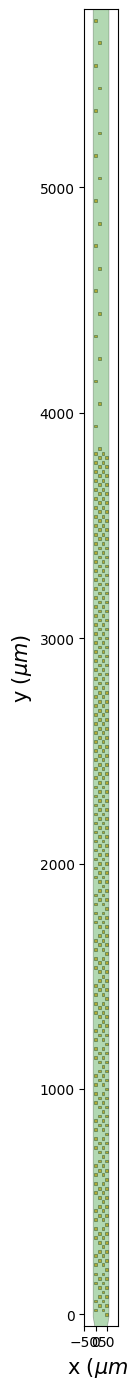

In [5]:
# PROBE SETUP
#
#   1) Geometry already in the file        -> use it as-is, nothing to do.
#   2) Manual map provided                 -> tetrode array (tetrode_config), or flat
#                                             (x, y) positions typed in / loaded from a
#                                             NumPy (.npy) file. If channel_label_csv is
#                                             also given, relabel + print the mapping for
#                                             a visual double-check before it's used.
#   3) Nothing available                   -> fall back to a "dummy" probe where every
#                                             channel is placed very far from the others.
#
# IMPORTANT: option 3 is a safety net, not a real fix. If data ends up using the
# dummy probe, sorting quality will likely suffer for anything that relies on spatial
# information. Use option 2 whenever the real layout is known.

import pandas as pd
from probeinterface import Probe, combine_probes

n_ch = raw_rec.get_num_channels()

_original_channel_ids = raw_rec.channel_ids.copy()

# STEP 1: geometry already in the file
_has_geometry = False
try:
    raw_rec.get_probe()
    _has_geometry = True
    print(f"[probe] Geometry already in the file ({n_ch} channels).")
except ValueError:
    print("[probe] Step 1: no geometry found in the file.")

#  STEP 2a: tetrode array (groups of closely-spaced contacts, each an
#  independent shank).
if not _has_geometry and tetrode_config is not None:
    _offsets_in = tetrode_config['contact_offsets_um']
    _offsets    = np.load(_offsets_in) if isinstance(_offsets_in, (str, Path)) else np.array(_offsets_in, dtype=float)

    _n_tet     = tetrode_config['n_tetrodes']
    _spacing   = tetrode_config['tetrode_spacing_um']
    _radius    = tetrode_config.get('contact_radius_um', 7.5)

    _dev_idx_in = tetrode_config.get('device_channel_indices', None)
    if isinstance(_dev_idx_in, (str, Path)):
        _dev_idx = np.load(_dev_idx_in)
    elif _dev_idx_in is not None:
        _dev_idx = np.asarray(_dev_idx_in)
    else:
        _dev_idx = None

    _n_contacts_per_tetrode = len(_offsets)

    if _n_tet * _n_contacts_per_tetrode != n_ch:
        raise ValueError(
            f"tetrode_config describes {_n_tet} tetrodes x {_n_contacts_per_tetrode} contacts "
            f"= {_n_tet * _n_contacts_per_tetrode} contacts, but raw_rec has {n_ch} channels."
        )

    _tetrode_probes = []
    for _t in range(_n_tet):
        _tp = Probe(ndim=2, si_units='um')
        _tp.set_contacts(positions=_offsets.copy(), shapes='circle', shape_params={'radius': _radius})
        _tp.move([0, _t * _spacing])
        _tp.set_shank_ids([_t] * _tp.get_contact_count())
        _tetrode_probes.append(_tp)

    probe = combine_probes(_tetrode_probes)
    probe.create_auto_shape(probe_type='tip')

    if _dev_idx is not None:
        if len(_dev_idx) != n_ch:
            raise ValueError(
                f"tetrode_config['device_channel_indices'] has {len(_dev_idx)} entries, "
                f"expected {n_ch} to match raw_rec channels."
            )
        probe.set_device_channel_indices(_dev_idx)
        print(f"[probe] Tetrode array: {_n_tet} tetrodes x {_n_contacts_per_tetrode} contacts, "
              f"custom device wiring applied.")
    else:
        probe.set_device_channel_indices(np.arange(n_ch))
        print(f"[probe] Tetrode array: {_n_tet} tetrodes x {_n_contacts_per_tetrode} contacts, "
              f"identity wiring (contact i -> device channel i).")

    raw_rec = raw_rec.set_probe(probe, group_mode='by_shank')
    raw_rec = raw_rec.rename_channels(_original_channel_ids)  # restore original ids
    _has_geometry = True
    print(f"[probe] Tetrode array attached ({n_ch} channels, {_n_tet} shanks).")

#  STEP 2b: flat manual map (.npy positions, or a literal dict) + optional CSV relabel
if not _has_geometry:
    _positions = None
    if manual_probe_npy is not None:
        _xy = np.load(manual_probe_npy)
        if _xy.shape != (n_ch, 2):
            raise ValueError(f"manual_probe_npy has shape {_xy.shape}, expected ({n_ch}, 2)")
        _positions = {str(c): tuple(_xy[i]) for i, c in enumerate(raw_rec.channel_ids)}
    elif manual_probe_map is not None:
        _positions = manual_probe_map

    # optional: relabel channels using a CSV (channel_index -> electrode_label),
    # printed so the coupling can be checked, and used to re-key _positions
    if channel_label_csv is not None:
        _new_labels = pd.read_csv(channel_label_csv)['electrode_label'].astype(str).tolist()
        if len(_new_labels) != n_ch:
            raise ValueError(f"channel_label_csv has {len(_new_labels)} rows, expected {n_ch}")
        print(pd.DataFrame({'channel_index': range(n_ch), 'electrode_label': _new_labels}).to_string(index=False))
        if _positions is not None:
            _positions = {_new_labels[i]: _positions[str(c)] for i, c in enumerate(raw_rec.channel_ids)}
        raw_rec = raw_rec.rename_channels(_new_labels)
        _original_channel_ids = raw_rec.channel_ids.copy()  # relabeled ids are now "original"

    if _positions is not None:
        _missing = [c for c in raw_rec.channel_ids if str(c) not in _positions]
        if _missing:
            raise ValueError(f"manual map is missing positions for channels: {_missing}")
        _ordered_xy = np.array([_positions[str(c)] for c in raw_rec.channel_ids], dtype=float)

        probe = Probe(ndim=2, si_units='um')
        probe.set_contacts(positions=_ordered_xy, shapes='circle', shape_params={'radius': 7.5})
        probe.create_auto_shape(probe_type='tip')
        probe.set_device_channel_indices(np.arange(n_ch))
        raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
        raw_rec = raw_rec.rename_channels(_original_channel_ids)  # restore original (or relabeled) ids
        _has_geometry = True
        print(f"[probe] Manual map attached ({n_ch} channels).")
    else:
        print("[probe] No manual map provided (tetrode_config / manual_probe_map / manual_probe_npy are all None).")

# STEP 3: fallback dummy probe
if not _has_geometry:
    _dummy_spacing_um = 1000.    #largest channel-neighborhood radius found is 100 um, so to be sure of independence set to 1000 um
    probe = Probe(ndim=2, si_units='um')
    probe.set_contacts(
        positions=np.column_stack([np.arange(n_ch, dtype=float) * _dummy_spacing_um, np.zeros(n_ch)]),
        shapes='circle', shape_params={'radius': 7.5},
    )
    probe.create_auto_shape(probe_type='tip')
    probe.set_device_channel_indices(np.arange(n_ch))
    raw_rec = raw_rec.set_probe(probe, group_mode='by_probe')
    raw_rec = raw_rec.rename_channels(_original_channel_ids)  # restore original ids
    _has_geometry = True
    print(f"[probe] Using a dummy probe (fallback). All {n_ch} channels are spaced "
          f"{_dummy_spacing_um:.0f} um apart so the sorter treats them as spatially independent. "
          f"This is NOT real geometry, provide manual_probe_map or manual_probe_npy for proper results.")

# PROBE MAP (visual check).
# Label channel ids individually only when there are few enough contacts for
# the text to stay readable (dense arrays like Neuropixels would otherwise
# render as an illegible smear of overlapping labels).
_label_max_channels = 64
_with_labels = n_ch <= _label_max_channels

_aspect_h = max(6., min(14., 6. * (raw_rec.get_probe().contact_positions[:, 1].ptp() /
                                    max(raw_rec.get_probe().contact_positions[:, 0].ptp(), 1.)) ** 0.5))
fig, ax = plt.subplots(figsize=(6, _aspect_h))
si.plot_probe_map(raw_rec, with_channel_ids=_with_labels, ax=ax)

_contact_xy = raw_rec.get_probe().contact_positions
_margin_um  = 50.
_x_min, _x_max = _contact_xy[:, 0].min() - _margin_um, _contact_xy[:, 0].max() + _margin_um
_y_min, _y_max = _contact_xy[:, 1].min() - _margin_um, _contact_xy[:, 1].max() + _margin_um
ax.set_xlim(_x_min, _x_max)
ax.set_ylim(_y_min, _y_max)

plt.tight_layout()
plt.show()


In [6]:
# PREPROCESSING
_n_raw_channels = raw_rec.get_num_channels()

if FORMAT == 'spikeglx':
    rec1 = si.phase_shift(raw_rec)
    rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)
else:
    rec1 = si.highpass_filter(raw_rec, freq_min=freq_min)

bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)

rec2 = rec1.remove_channels(bad_channel_ids)

if FORMAT == 'spikeglx':
    rec2 = si.phase_shift(rec2)

rec = si.common_reference(rec2, operator=cref_operator, reference=cref_reference)
print(rec)

# Bad-channel label export (MCS-specific in the original pipeline; harmless for all formats)
_bad_labels = []
for _ch in bad_channel_ids:
    _idx = np.where(rec1.channel_ids == _ch)[0]
    _bad_labels.append(str(channel_labels[_idx[0]]) if len(_idx) > 0 else 'auto')
with open(base_folder / 'bad_channels.csv', 'w') as _f:
    _f.write('channel_id,label\n')
    for _c, _l in zip(bad_channel_ids, _bad_labels):
        _f.write(f'{_c},{_l}\n')
print(f'Bad channels ({len(bad_channel_ids)}) saved -> {base_folder / "bad_channels.csv"}')


CommonReferenceRecording: 381 channels - 30000.415126 Hz - 1 segments - 150,002 samples - 5.00s 
                          int16 dtype - 109.01 MiB
Bad channels (3) saved -> C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\prototype_output\bad_channels.csv


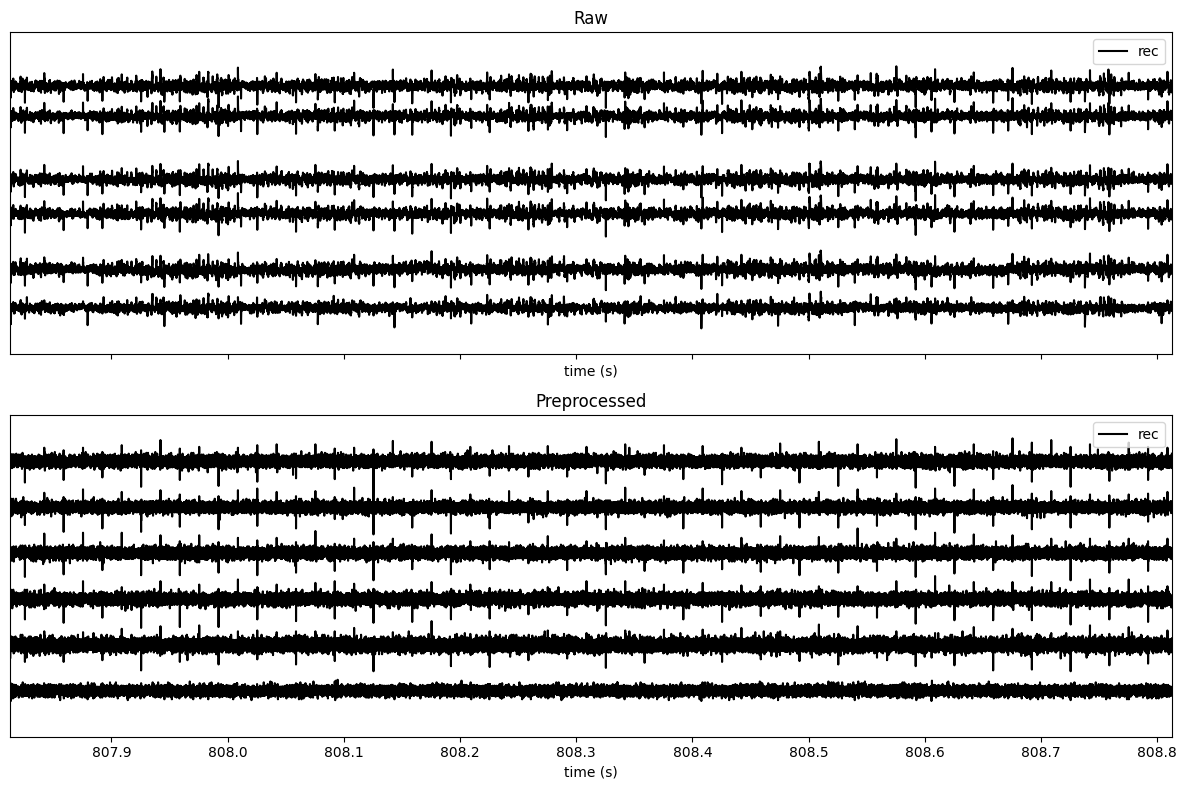

In [7]:
# TRACES VISUALIZATION
import re
_fs    = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

_nat_key     = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_good_ch_ids = [c for c in sorted(raw_rec.channel_ids, key=_nat_key) if c in set(rec.channel_ids)]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
si.plot_traces(raw_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[0])
si.plot_traces(rec_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[1])
axes[0].set_title('Raw')
axes[1].set_title('Preprocessed')
plt.tight_layout()
plt.show()

In [8]:
# SAVE PREPROCESSED RECORDING
import gc, shutil
try: del analyzer
except NameError: pass
try: del rec_analysis
except NameError: pass
try: del raw_rec
except NameError: pass
try: del rec1
except NameError: pass
try: del rec2
except NameError: pass
try: del rec3
except NameError: pass
gc.collect()

87

In [9]:
# Windows fix I needed to add, otherwise the file got locked out and I kept having an error, NOT NEEDED IN FINAL CODE
_pf = base_folder / 'preprocess'
_pf_loaded = False
if _pf.exists():
    try:
        rec = si.load(_pf)
        _pf_loaded = True
        print(f'Loaded existing preprocessed recording (delete {_pf} to force re-saving)')
    except Exception:
        _pf = base_folder / 'preprocess_new'
        shutil.rmtree(_pf, ignore_errors=True)
        print('Existing preprocess folder is locked/corrupt — saving to preprocess_new')
if not _pf_loaded:
    rec = rec.save(folder=_pf, format='binary',
                   overwrite=True, n_jobs=1, chunk_duration='1s', progress_bar=True)
    print(f'Preprocessed recording saved -> {_pf}')

Loaded existing preprocessed recording (delete C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\prototype_output\preprocess to force re-saving)


In [10]:
# SPIKE SORTING
sorting = si.run_sorter(sorter, rec, folder=base_folder / f'{sorter}_output',
                        remove_existing_folder=True, verbose=True)
print(sorting)

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing preprocessing variables.
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: N samples: 900000
kilosort.run_kilosort: N seconds: 29.99958487974424
kilosort.run_kilosort: N batches: 15
kilosort.run_kilosort: Preprocessing filters computed in  4.57s; total  4.57s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after preprocessing
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    23.40 %
kilosort.run_kilosort: Mem used:     31.70 %     |      10.04 GB
kilosort.run_kilosort: Mem avail:    21.67 / 31.71 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    N/A
kilosort.run_kilosort: GPU memory:   N/A
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
ki

kilosort4 run time 1682.25s
KiloSortSortingExtractor: 95 units - 1 segments - 30.0kHz


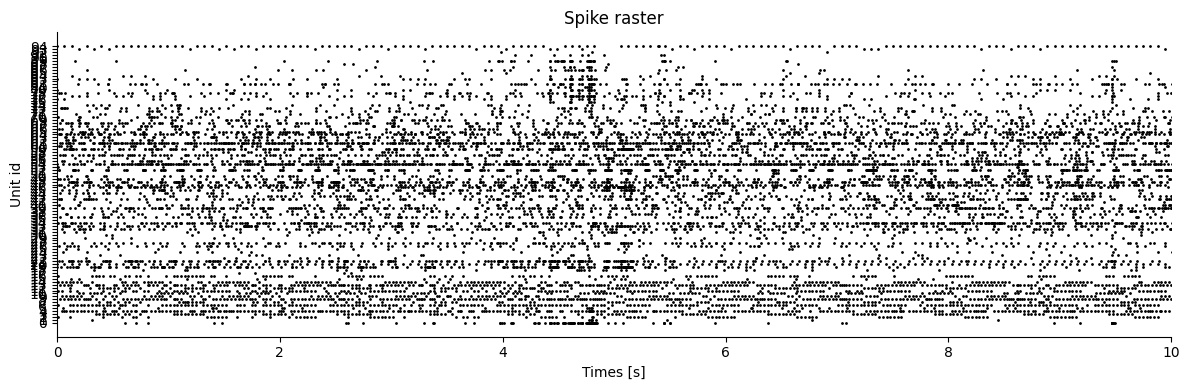

In [11]:
# RASTER PLOT 

fig, ax = plt.subplots(figsize=(12, 4))
si.plot_rasters(sorting, time_range=[0, min(10, rec.get_total_duration())], ax=ax)
ax.set_title('Spike raster')
plt.tight_layout()
plt.show()

In [14]:
# SORTING ANALYZER
si.set_global_job_kwargs(n_jobs=1, chunk_duration='1s', progress_bar=True)

rec_analysis = si.load(_pf)

analyzer = si.create_sorting_analyzer(sorting, rec_analysis, sparse=_analyzer_sparse, format='memory')

analyzer.compute('random_spikes', method='uniform', max_spikes_per_unit=max_spikes_per_unit)
analyzer.compute('waveforms', ms_before=waveform_ms_before, ms_after=waveform_ms_after)
analyzer.compute('templates', operators=['average', 'median', 'std'])
analyzer.compute('noise_levels')
analyzer.compute('correlograms')
analyzer.compute('unit_locations')
analyzer.compute('spike_amplitudes')
analyzer.compute('template_similarity')
analyzer.compute('spike_locations')  

if FORMAT == 'spikeglx':
    analyzer.compute('template_metrics', metric_names=template_metric_names)  

if compute_pca_metrics:
    analyzer.compute('principal_components', n_components=pca_n_components, mode=pca_mode)

print(analyzer)

estimate_sparsity (no parallelization):   0%|          | 0/31 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/31 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/31 [00:00<?, ?it/s]

spike_locations (no parallelization):   0%|          | 0/31 [00:00<?, ?it/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\template\template_metrics.py:301: UserWarning: With less than 10 channels, multi-channel metrics might not be reliable.
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\template\metrics.py:936: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\template\metrics.py:936: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\sklearn\metrics\_regression.py:1283: UndefinedMetricWarning: R^2 score is not wel

Fitting PCA:   0%|          | 0/95 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/95 [00:00<?, ?it/s]

SortingAnalyzer: 381 channels - 95 units - 1 segments - memory - sparse - has recording
Loaded 11 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, spike_locations, template_metrics, principal_components


In [15]:
# QUALITY METRICS
metrics_ext = analyzer.compute('quality_metrics', metric_names=metric_names,
                               metric_params=metric_extension_params)
metrics = metrics_ext.get_data()

# merge in template (waveform-shape) metrics so the exported table matches
# the UnitRefine training_data.csv column set (Neuropixels / spikeglx only)
if FORMAT == 'spikeglx':
    template_metrics = analyzer.get_extension('template_metrics').get_data()
    metrics = metrics.join(template_metrics)

print(metrics)
metrics.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved -> {base_folder / 'quality_metrics.csv'}")

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:98: UserWarning: Bin duration of 60s is larger than recording duration. Presence ratios are set to NaN.
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning: Amplitude cutoff set to NaN for units [1, 2, 3, 5, 7, 9, 10, 12, 14, 15, 16, 17, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 35, 36, 37, 38, 40, 41, 43, 44, 45, 49, 50, 51, 53, 56, 58, 60, 62, 65, 66, 67, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]: too few spikes (< 500).
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1323: UserWarning: Drift metrics could not be computed for units [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,

    num_spikes  firing_rate  presence_ratio        snr  isi_violations_ratio  \
0          838    27.933347             NaN   1.958196              3.175533   
1           35     1.166667             NaN   6.475102             40.816306   
2          306    10.200005             NaN  11.691156              0.000000   
3          324    10.800005             NaN  12.605219              0.000000   
4          836    27.866681             NaN   7.397629              0.028617   
..         ...          ...             ...        ...                   ...   
90           4     0.133333             NaN   2.403355              0.000000   
91          81     2.700001             NaN   1.958196              6.096629   
92          11     0.366667             NaN   1.305464              0.000000   
93          98     3.266668             NaN   7.941573              0.000000   
94         385    12.833340             NaN   8.267939              0.067465   

    isi_violations_count  rp_contaminat

In [16]:
# QUALITY-BASED FILTERING
_conditions = []
if not metrics['amplitude_cutoff'].isna().all():
    _conditions.append(f"(amplitude_cutoff < {amplitude_cutoff_thresh})")
_conditions.append(f"(isi_violations_ratio < {isi_violations_ratio_thresh})")
if not metrics['presence_ratio'].isna().all():
    _conditions.append(f"(presence_ratio > {presence_ratio_thresh})")
query = " & ".join(_conditions)

keep_unit_ids = np.asarray(metrics.query(query).index.tolist(), dtype=sorting.unit_ids.dtype)
print(f"Keeping {len(keep_unit_ids)} / {len(sorting.unit_ids)} units after quality filtering")
if metrics['amplitude_cutoff'].isna().all():
    print("Note: amplitude_cutoff skipped (all NaN, too few spikes per unit)")
if metrics['presence_ratio'].isna().all():
    print("Note: presence_ratio skipped (all NaN, recording shorter than 60s bin)")

analyzer = analyzer.select_units(keep_unit_ids)

Keeping 24 / 95 units after quality filtering
Note: presence_ratio skipped (all NaN, recording shorter than 60s bin)


In [18]:
if FORMAT == 'spikeglx':
    import spikeinterface.curation as sc

    # Apply the noise/neural model
    noise_neuron_labels = sc.auto_label_units(
        sorting_analyzer=analyzer,
        repo_id="AnoushkaJain3/noise_neural_classifier_lightweight",
        trusted=['numpy.dtype'],
    )

    noise_units = noise_neuron_labels[noise_neuron_labels['prediction'] == 'noise']
    analyzer_neural = analyzer.remove_units(noise_units.index)

    # Apply the sua/mua model
    sua_mua_labels = sc.auto_label_units(
        sorting_analyzer=analyzer_neural,
        repo_id="AnoushkaJain3/sua_mua_classifier_lightweight",
        trusted=['numpy.dtype'],
    )

    all_labels = pd.concat([sua_mua_labels, noise_units]).sort_index()
    print(all_labels)

C:\Users\labuser\AppData\Local\Temp\ipykernel_4396\3232872987.py:5: DeprecationWarning: `auto_label_units` is deprecated and will be removed in v0.105.0. Please use `model_based_label_units` instead.
  noise_neuron_labels = sc.auto_label_units(


best_model.skops:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\labuser\.cache\huggingface\hub\models--AnoushkaJain3--noise_neural_classifier_lightweight. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


metadata.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

model_info.json:   0%|          | 0.00/202 [00:00<?, ?B/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from 

ValueError: ('Input data does not contain all required metrics for classification', "Missing metrics: {'num_positive_peaks', 'num_negative_peaks'}")

In [ ]:
# PER-UNIT DIAGNOSTIC PLOTS 

#needed?? just found on internet

_n_preview = min(6, len(keep_unit_ids))
_preview_units = keep_unit_ids[:_n_preview]

# Waveform shapes 
fig1 = plt.figure(figsize=(3 * _n_preview, 5))
si.plot_unit_waveforms(analyzer, unit_ids=_preview_units, figure=fig1)
plt.suptitle('Unit waveforms (first {} kept units)'.format(_n_preview))
plt.tight_layout()
plt.show()

# Amplitude over time 
fig2, ax2 = plt.subplots(figsize=(10, 4))
si.plot_amplitudes(analyzer, unit_ids=_preview_units, ax=ax2)
ax2.set_title('Spike amplitude over time')
plt.tight_layout()
plt.show()

# Quality metric overview 
fig3 = plt.figure(figsize=(10, 8))
si.plot_quality_metrics(analyzer, figure=fig3)
plt.tight_layout()
plt.show()


In [ ]:
# PIPELINE LOG
import json as _json, datetime as _dt

_log = {
    'timestamp':       _dt.datetime.now().isoformat(),
    'si_version':      si.__version__,
    'format':          FORMAT,
    'source_path':     _source_path,
    'sorter':          sorter,
    'n_channels_raw':  int(_n_raw_channels),
    'n_channels_kept': int(rec_analysis.get_num_channels()),
    'bad_channel_ids': [str(c) for c in bad_channel_ids],
    'n_units_sorted':  int(len(sorting.unit_ids)),
    'n_units_kept':    int(len(keep_unit_ids)),
    'parameters': {
        'freq_min':                    freq_min,
        'cref_operator':               cref_operator,
        'cref_reference':              cref_reference,
        'waveform_ms_before':          waveform_ms_before,
        'waveform_ms_after':           waveform_ms_after,
        'max_spikes_per_unit':         max_spikes_per_unit,
        'amplitude_cutoff_thresh':     amplitude_cutoff_thresh,
        'isi_violations_ratio_thresh': isi_violations_ratio_thresh,
        'presence_ratio_thresh':       presence_ratio_thresh,
    },
}
_log_path = base_folder / 'pipeline_run_log.json'
_log_path.write_text(_json.dumps(_log, indent=2))
print(f'Run log -> {_log_path}')

In [ ]:
# SAVE ANALYZER
import shutil
_analyzer_folder = base_folder / 'analyzer'
if _analyzer_folder.exists():
    shutil.rmtree(_analyzer_folder)
analyzer.save_as(folder=_analyzer_folder, format='binary_folder')

In [ ]:
# INTERACTIVE VIEWER (sigui)

import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)